<a href="https://colab.research.google.com/github/sabinrajpokhrel/Wildfire_ML_Project/blob/main/Wildfire_Model_Training_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wildfire Risk Prediction Model for Nepal

## Final Next-Day Model Training and Hardware-Compatible Deployment Bundle

This notebook trains and evaluates two models using the corrected ERA5-Land and
NASA FIRMS dataset:

1. **Full environmental benchmark model**
2. **Hardware-compatible next-day risk model**

The deployable model estimates the risk of a NASA FIRMS hotspot being detected
in the same geographic grid cell on the following day.

The hardware model uses only variables that can be reproduced from:

- DHT11 temperature
- DHT11 humidity
- derived dew point
- GPS or configured deployment coordinates
- stored 3-day and 7-day daily sensor history
- date and Nepal seasonality

MQ2 and flame remain separate immediate detection rules and are not ML inputs.

## Important execution notes

- Use the corrected dataset:
  `wildfire_base_grid_daily_same_day_full_rerun_v2.parquet`
- Do not reuse the old model trained from the incomplete March-May FIRMS labels.
- The notebook must show positive examples in training, validation, and testing.
- The output is a **wildfire risk score**, not an exact physical probability of ignition.
- The final deployable file will be:
  `wildfire_hardware_next_day_v1.joblib`

In [1]:
import json
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")
print("scikit-learn version:", sklearn.__version__)

Libraries imported successfully.
scikit-learn version: 1.6.1


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
PROJECT_FOLDER = Path(
    "/content/drive/MyDrive/Wildfire_ML_Project"
)

MODEL_FOLDER = PROJECT_FOLDER / "models"
RESULTS_FOLDER = PROJECT_FOLDER / "results"

MODEL_FOLDER.mkdir(parents=True, exist_ok=True)
RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)

BASE_DATASET_PATH = (
    PROJECT_FOLDER
    / "wildfire_base_grid_daily_same_day_full_rerun_v2.parquet"
)

assert BASE_DATASET_PATH.exists(), (
    "Corrected dataset was not found: "
    f"{BASE_DATASET_PATH}"
)

print("Project folder:", PROJECT_FOLDER)
print("Corrected base dataset:", BASE_DATASET_PATH)

Project folder: /content/drive/MyDrive/Wildfire_ML_Project
Corrected base dataset: /content/drive/MyDrive/Wildfire_ML_Project/wildfire_base_grid_daily_same_day_full_rerun_v2.parquet


## 2. Load and Validate the Corrected Labelled Dataset

In [4]:
wildfire = pd.read_parquet(
    BASE_DATASET_PATH
)

wildfire["date"] = pd.to_datetime(
    wildfire["date"],
    errors="coerce"
).dt.normalize()

wildfire = (
    wildfire
    .sort_values(
        ["latitude", "longitude", "date"]
    )
    .reset_index(drop=True)
)

print("Dataset loaded successfully.")
print("Shape:", wildfire.shape)

Dataset loaded successfully.
Shape: (680500, 20)


In [5]:
required_columns = {
    "date",
    "latitude",
    "longitude",
    "temperature_mean_c",
    "temperature_max_c",
    "dewpoint_c",
    "relative_humidity",
    "u_wind_mps",
    "v_wind_mps",
    "wind_speed_mps",
    "precipitation_mm",
    "soil_moisture",
    "fire_detected",
}

missing_required_columns = (
    required_columns - set(wildfire.columns)
)

assert not missing_required_columns, (
    "Required columns are missing: "
    f"{sorted(missing_required_columns)}"
)

unique_grid_cells = (
    wildfire[
        ["latitude", "longitude"]
    ]
    .drop_duplicates()
    .shape[0]
)

duplicate_grid_dates = wildfire.duplicated(
    ["date", "latitude", "longitude"]
).sum()

missing_values = wildfire.isna().sum().sum()

same_day_positive_count = int(
    wildfire["fire_detected"].sum()
)

post_march_same_day_positives = int(
    wildfire.loc[
        wildfire["date"]
        >= pd.Timestamp("2026-03-01"),
        "fire_detected"
    ].sum()
)

print("Date range:", wildfire["date"].min(), "to", wildfire["date"].max())
print("Unique dates:", wildfire["date"].nunique())
print("Unique grid cells:", unique_grid_cells)
print("Duplicate grid-cell dates:", duplicate_grid_dates)
print("Missing values:", missing_values)
print("Same-day positive labels:", same_day_positive_count)
print("Positive labels from March 2026 onward:", post_march_same_day_positives)

assert len(wildfire) == 680_500
assert wildfire["date"].nunique() == 500
assert unique_grid_cells == 1361
assert duplicate_grid_dates == 0
assert missing_values == 0
assert wildfire["date"].min() == pd.Timestamp("2025-01-05")
assert wildfire["date"].max() == pd.Timestamp("2026-05-19")
assert post_march_same_day_positives > 0, (
    "The corrected file still has no positive labels "
    "after February 2026."
)

print("Corrected base-dataset validation passed.")

Date range: 2025-01-05 00:00:00 to 2026-05-19 00:00:00
Unique dates: 500
Unique grid cells: 1361
Duplicate grid-cell dates: 0
Missing values: 0
Same-day positive labels: 3461
Positive labels from March 2026 onward: 1201
Corrected base-dataset validation passed.


In [6]:
monthly_same_day_labels = (
    wildfire
    .assign(
        month=(
            wildfire["date"]
            .dt.to_period("M")
            .astype(str)
        )
    )
    .groupby(
        "month",
        as_index=False
    )
    .agg(
        positive_grid_cell_days=(
            "fire_detected",
            "sum"
        )
    )
)

monthly_same_day_labels.tail(10)

,month,positive_grid_cell_days
7,2025-08,0
8,2025-09,1
9,2025-10,2
10,2025-11,76
11,2025-12,103
12,2026-01,135
13,2026-02,131
14,2026-03,194
15,2026-04,984
16,2026-05,23


## 3. Construct the Next-Day Prediction Target

For each geographic grid cell:

- Features represent environmental conditions on day `t`.
- The target represents FIRMS hotspot detection on day `t + 1`.

In [7]:
wildfire["fire_next_day"] = (
    wildfire
    .groupby(
        ["latitude", "longitude"]
    )["fire_detected"]
    .shift(-1)
)

rows_before_target_drop = len(wildfire)

wildfire = wildfire.dropna(
    subset=["fire_next_day"]
).copy()

wildfire["fire_next_day"] = (
    wildfire["fire_next_day"]
    .astype("int8")
)

rows_removed = (
    rows_before_target_drop - len(wildfire)
)

print("Rows removed without a next-day label:", rows_removed)
print("Remaining modelling rows:", len(wildfire))
print("Positive next-day examples:", int(wildfire["fire_next_day"].sum()))

assert rows_removed == 1361
assert len(wildfire) == 679_139

Rows removed without a next-day label: 1361
Remaining modelling rows: 679139
Positive next-day examples: 3461


In [8]:
TARGET_PERIODS = {
    "Training": {
        "start": pd.Timestamp("2025-01-05"),
        "end": pd.Timestamp("2025-12-31"),
    },
    "Validation": {
        "start": pd.Timestamp("2026-01-01"),
        "end": pd.Timestamp("2026-02-28"),
    },
    "Testing": {
        "start": pd.Timestamp("2026-03-01"),
        "end": pd.Timestamp("2026-05-18"),
    },
}

target_period_rows = []

for period_name, period_dates in TARGET_PERIODS.items():
    period_mask = wildfire["date"].between(
        period_dates["start"],
        period_dates["end"]
    )

    period_row_count = int(
        period_mask.sum()
    )

    period_positive_count = int(
        wildfire.loc[
            period_mask,
            "fire_next_day"
        ].sum()
    )

    target_period_rows.append({
        "period": period_name,
        "input_start_date": period_dates["start"],
        "input_end_date": period_dates["end"],
        "rows": period_row_count,
        "positive_next_day_labels": period_positive_count,
        "positive_percentage": (
            period_positive_count
            / period_row_count
            * 100
        ),
    })

target_period_summary = pd.DataFrame(
    target_period_rows
)

display(
    target_period_summary
)

assert (
    target_period_summary[
        "positive_next_day_labels"
    ] > 0
).all(), (
    "At least one modelling period contains "
    "no positive next-day labels."
)

assert int(
    target_period_summary["rows"].sum()
) == len(wildfire)

print(
    "Training, validation, and testing all "
    "contain positive next-day labels."
)

,period,input_start_date,input_end_date,rows,positive_next_day_labels,positive_percentage
0,Training,2025-01-05,2025-12-31,491321,1997,0.406455
1,Validation,2026-01-01,2026-02-28,80299,280,0.348697
2,Testing,2026-03-01,2026-05-18,107519,1184,1.101201


Training, validation, and testing all contain positive next-day labels.


## 4. Reproducible Feature Engineering

In [9]:
GROUP_COLUMNS = [
    "latitude",
    "longitude"
]

SEASON_CATEGORIES = [
    "winter",
    "pre_monsoon",
    "monsoon",
    "post_monsoon",
]


def calculate_consecutive_dry_days(
    precipitation_series,
    threshold_mm=1.0
):
    dry_day = precipitation_series < threshold_mm
    reset_group = (~dry_day).cumsum()

    return (
        dry_day
        .groupby(reset_group)
        .cumsum()
        .astype("int16")
    )


def add_model_features(dataframe):
    data = (
        dataframe
        .sort_values(
            GROUP_COLUMNS + ["date"]
        )
        .reset_index(drop=True)
        .copy()
    )

    grouped = data.groupby(
        GROUP_COLUMNS,
        sort=False
    )

    for window in [3, 7, 14]:
        data[f"rainfall_sum_{window}d"] = (
            grouped["precipitation_mm"]
            .transform(
                lambda values, w=window:
                values.rolling(
                    window=w,
                    min_periods=1
                ).sum()
            )
        )

    for window in [3, 7]:
        data[f"humidity_mean_{window}d"] = (
            grouped["relative_humidity"]
            .transform(
                lambda values, w=window:
                values.rolling(
                    window=w,
                    min_periods=1
                ).mean()
            )
        )

        data[f"temperature_mean_{window}d"] = (
            grouped["temperature_mean_c"]
            .transform(
                lambda values, w=window:
                values.rolling(
                    window=w,
                    min_periods=1
                ).mean()
            )
        )

        data[f"temperature_max_{window}d"] = (
            grouped["temperature_max_c"]
            .transform(
                lambda values, w=window:
                values.rolling(
                    window=w,
                    min_periods=1
                ).max()
            )
        )

        data[f"dewpoint_mean_{window}d"] = (
            grouped["dewpoint_c"]
            .transform(
                lambda values, w=window:
                values.rolling(
                    window=w,
                    min_periods=1
                ).mean()
            )
        )

    data["wind_speed_max_3d"] = (
        grouped["wind_speed_mps"]
        .transform(
            lambda values:
            values.rolling(
                window=3,
                min_periods=1
            ).max()
        )
    )

    data["wind_speed_mean_7d"] = (
        grouped["wind_speed_mps"]
        .transform(
            lambda values:
            values.rolling(
                window=7,
                min_periods=1
            ).mean()
        )
    )

    data["soil_moisture_mean_7d"] = (
        grouped["soil_moisture"]
        .transform(
            lambda values:
            values.rolling(
                window=7,
                min_periods=1
            ).mean()
        )
    )

    data["consecutive_dry_days"] = (
        grouped["precipitation_mm"]
        .transform(
            calculate_consecutive_dry_days
        )
    )

    data["month"] = (
        data["date"]
        .dt.month
        .astype("int8")
    )

    data["day_of_year"] = (
        data["date"]
        .dt.dayofyear
        .astype("int16")
    )

    data["day_of_year_sin"] = np.sin(
        2
        * np.pi
        * data["day_of_year"]
        / 365.25
    )

    data["day_of_year_cos"] = np.cos(
        2
        * np.pi
        * data["day_of_year"]
        / 365.25
    )

    data["season_winter"] = (
        data["month"].isin([12, 1, 2])
        .astype("int8")
    )

    data["season_pre_monsoon"] = (
        data["month"].isin([3, 4, 5])
        .astype("int8")
    )

    data["season_monsoon"] = (
        data["month"].isin([6, 7, 8, 9])
        .astype("int8")
    )

    data["season_post_monsoon"] = (
        data["month"].isin([10, 11])
        .astype("int8")
    )

    return data

In [10]:
feature_engineering_start = time.time()

wildfire = add_model_features(
    wildfire
)

feature_engineering_minutes = (
    time.time() - feature_engineering_start
) / 60

print(
    "Feature engineering completed in",
    round(feature_engineering_minutes, 2),
    "minutes."
)

print(
    "Dataset shape after feature engineering:",
    wildfire.shape
)

Feature engineering completed in 0.14 minutes.
Dataset shape after feature engineering: (679139, 44)


In [11]:
ENGINEERED_FEATURES = [
    "rainfall_sum_3d",
    "rainfall_sum_7d",
    "rainfall_sum_14d",
    "humidity_mean_3d",
    "humidity_mean_7d",
    "temperature_mean_3d",
    "temperature_mean_7d",
    "temperature_max_3d",
    "temperature_max_7d",
    "dewpoint_mean_3d",
    "dewpoint_mean_7d",
    "wind_speed_max_3d",
    "wind_speed_mean_7d",
    "soil_moisture_mean_7d",
    "consecutive_dry_days",
    "month",
    "day_of_year",
    "day_of_year_sin",
    "day_of_year_cos",
    "season_winter",
    "season_pre_monsoon",
    "season_monsoon",
    "season_post_monsoon",
]

engineered_missing_values = (
    wildfire[
        ENGINEERED_FEATURES
    ]
    .isna()
    .sum()
    .sum()
)

print(
    "Missing engineered values:",
    engineered_missing_values
)

assert engineered_missing_values == 0

Missing engineered values: 0


## 5. Define the Research and Hardware Feature Sets

### Full environmental model

The full model uses ERA5 weather, recent weather history, location, and seasonality.

### Hardware-compatible model

The hardware model uses only quantities that can be produced from:

- DHT11 temperature
- DHT11 humidity
- GPS or configured deployment coordinates
- Timestamp
- Stored daily sensor history

`MQ2` and `flame` are deliberately excluded from model training because there are no corresponding historical MQ2/flame measurements in the ERA5-FIRMS dataset. They remain part of the immediate rule-based detection layer.

In [12]:
LEAKAGE_COLUMNS = {
    "fire_detected",
    "fire_next_day",
    "fire_count",
    "frp_sum",
    "frp_max",
    "confidence_mean",
    "brightness_mean",
    "match_distance_mean_km",
    "match_distance_max_km",
}

SEASON_COLUMNS = [
    "season_winter",
    "season_pre_monsoon",
    "season_monsoon",
    "season_post_monsoon",
]

FULL_MODEL_FEATURES = [
    "latitude",
    "longitude",
    "temperature_mean_c",
    "temperature_max_c",
    "dewpoint_c",
    "relative_humidity",
    "u_wind_mps",
    "v_wind_mps",
    "wind_speed_mps",
    "precipitation_mm",
    "soil_moisture",
    "rainfall_sum_3d",
    "rainfall_sum_7d",
    "rainfall_sum_14d",
    "humidity_mean_3d",
    "humidity_mean_7d",
    "temperature_mean_3d",
    "temperature_mean_7d",
    "temperature_max_3d",
    "temperature_max_7d",
    "dewpoint_mean_3d",
    "dewpoint_mean_7d",
    "wind_speed_max_3d",
    "wind_speed_mean_7d",
    "soil_moisture_mean_7d",
    "consecutive_dry_days",
    "month",
    "day_of_year_sin",
    "day_of_year_cos",
] + SEASON_COLUMNS

HARDWARE_MODEL_FEATURES = [
    "latitude",
    "longitude",
    "temperature_mean_c",
    "temperature_max_c",
    "dewpoint_c",
    "relative_humidity",
    "humidity_mean_3d",
    "humidity_mean_7d",
    "temperature_mean_3d",
    "temperature_mean_7d",
    "temperature_max_3d",
    "temperature_max_7d",
    "dewpoint_mean_3d",
    "dewpoint_mean_7d",
    "month",
    "day_of_year_sin",
    "day_of_year_cos",
] + SEASON_COLUMNS

FULL_MODEL_FEATURES = list(
    dict.fromkeys(FULL_MODEL_FEATURES)
)

HARDWARE_MODEL_FEATURES = list(
    dict.fromkeys(HARDWARE_MODEL_FEATURES)
)

for model_name, feature_columns in {
    "full": FULL_MODEL_FEATURES,
    "hardware": HARDWARE_MODEL_FEATURES,
}.items():
    leakage = set(feature_columns).intersection(
        LEAKAGE_COLUMNS
    )

    missing = (
        set(feature_columns)
        - set(wildfire.columns)
    )

    assert not leakage, (
        f"{model_name} model leakage: {leakage}"
    )

    assert not missing, (
        f"{model_name} model missing columns: "
        f"{sorted(missing)}"
    )

print(
    "Full model feature count:",
    len(FULL_MODEL_FEATURES)
)

print(
    "Hardware model feature count:",
    len(HARDWARE_MODEL_FEATURES)
)

Full model feature count: 33
Hardware model feature count: 21


In [13]:
MODEL_READY_PATH = (
    PROJECT_FOLDER
    / "wildfire_feature_engineered_next_day_v2.parquet"
)

wildfire.to_parquet(
    MODEL_READY_PATH,
    index=False,
    engine="pyarrow"
)

print(
    "Saved feature-engineered dataset:",
    MODEL_READY_PATH
)

Saved feature-engineered dataset: /content/drive/MyDrive/Wildfire_ML_Project/wildfire_feature_engineered_next_day_v2.parquet


## 6. Chronological Training, Validation, and Test Split

In [14]:
TRAIN_END = pd.Timestamp("2025-12-31")
VALIDATION_START = pd.Timestamp("2026-01-01")
VALIDATION_END = pd.Timestamp("2026-02-28")
TEST_START = pd.Timestamp("2026-03-01")
TEST_END = pd.Timestamp("2026-05-18")

train_mask = (
    wildfire["date"] <= TRAIN_END
)

validation_mask = wildfire["date"].between(
    VALIDATION_START,
    VALIDATION_END
)

test_mask = wildfire["date"].between(
    TEST_START,
    TEST_END
)

assigned_rows = (
    train_mask.astype(int)
    + validation_mask.astype(int)
    + test_mask.astype(int)
)

assert assigned_rows.min() == 1
assert assigned_rows.max() == 1

y_train = wildfire.loc[
    train_mask,
    "fire_next_day"
].copy()

y_validation = wildfire.loc[
    validation_mask,
    "fire_next_day"
].copy()

y_test = wildfire.loc[
    test_mask,
    "fire_next_day"
].copy()

assert y_train.sum() > 0
assert y_validation.sum() > 0
assert y_test.sum() > 0

print("Every row belongs to exactly one split.")

Every row belongs to exactly one split.


In [15]:
def summarise_split(
    name,
    mask,
    target
):
    return {
        "split": name,
        "first_date": (
            wildfire.loc[mask, "date"].min()
        ),
        "last_date": (
            wildfire.loc[mask, "date"].max()
        ),
        "rows": int(mask.sum()),
        "positive_examples": int(target.sum()),
        "positive_percentage": float(
            target.mean() * 100
        ),
    }


split_summary = pd.DataFrame([
    summarise_split(
        "Training",
        train_mask,
        y_train
    ),
    summarise_split(
        "Validation",
        validation_mask,
        y_validation
    ),
    summarise_split(
        "Testing",
        test_mask,
        y_test
    ),
])

split_summary

,split,first_date,last_date,rows,positive_examples,positive_percentage
0,Training,2025-01-05,2025-12-31,491321,1997,0.406455
1,Validation,2026-01-01,2026-02-28,80299,280,0.348697
2,Testing,2026-03-01,2026-05-18,107519,1184,1.101201


## 7. Random Forest Training Configuration

The final model uses the complete chronological training period by default.

This preserves the real negative-class distribution during fitting while
`class_weight="balanced_subsample"` increases the influence of rare hotspot
examples.

Set `USE_FULL_TRAINING_DATA = False` only for a temporary diagnostic run on
limited Colab hardware. A diagnostic model must not replace the final saved
deployment model.

In [17]:
USE_FULL_TRAINING_DATA = True
FAST_NEGATIVE_TO_POSITIVE_RATIO = 20

RANDOM_FOREST_PARAMETERS = {
    "n_estimators": 200,
    "max_depth": 18,
    "min_samples_split": 10,
    "min_samples_leaf": 4,
    "max_features": "sqrt",
    "class_weight": "balanced_subsample",
    "bootstrap": True,
    "max_samples": 0.50,
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
    "verbose": 1,
}

print(
    "Use full training data:",
    USE_FULL_TRAINING_DATA
)

print(
    "Random Forest parameters:",
    RANDOM_FOREST_PARAMETERS
)

Use full training data: True
Random Forest parameters: {'n_estimators': 200, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample', 'bootstrap': True, 'max_samples': 0.5, 'n_jobs': -1, 'random_state': 42, 'verbose': 1}


In [18]:
def prepare_training_frame(
    feature_columns
):
    training_frame = wildfire.loc[
        train_mask,
        feature_columns + ["fire_next_day"]
    ].copy()

    if USE_FULL_TRAINING_DATA:
        return training_frame

    positive_rows = training_frame.loc[
        training_frame["fire_next_day"] == 1
    ]

    negative_rows = training_frame.loc[
        training_frame["fire_next_day"] == 0
    ]

    negative_sample_size = min(
        len(negative_rows),
        len(positive_rows)
        * FAST_NEGATIVE_TO_POSITIVE_RATIO
    )

    sampled_negatives = negative_rows.sample(
        n=negative_sample_size,
        random_state=RANDOM_STATE
    )

    return (
        pd.concat(
            [
                positive_rows,
                sampled_negatives
            ],
            ignore_index=True
        )
        .sample(
            frac=1,
            random_state=RANDOM_STATE
        )
        .reset_index(drop=True)
    )


def train_random_forest(
    model_name,
    feature_columns
):
    training_frame = prepare_training_frame(
        feature_columns
    )

    X_fit = training_frame[
        feature_columns
    ]

    y_fit = training_frame[
        "fire_next_day"
    ]

    model = RandomForestClassifier(
        **RANDOM_FOREST_PARAMETERS
    )

    print(
        f"Training {model_name} model on",
        len(training_frame),
        "rows."
    )

    print(
        "Positive examples:",
        int(y_fit.sum())
    )

    print(
        "Negative examples:",
        int((y_fit == 0).sum())
    )

    start_time = time.time()

    model.fit(
        X_fit,
        y_fit
    )

    elapsed_minutes = (
        time.time() - start_time
    ) / 60

    print(
        f"{model_name} model trained in",
        round(elapsed_minutes, 2),
        "minutes."
    )

    return model

## 8. Train the Full Environmental Model

In [19]:
full_model = train_random_forest(
    model_name="Full environmental",
    feature_columns=FULL_MODEL_FEATURES
)

Training Full environmental model on 491321 rows.
Positive examples: 1997
Negative examples: 489324


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  4.6min


Full environmental model trained in 4.7 minutes.


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  4.7min finished


## 9. Train the Hardware-Compatible Model

In [20]:
hardware_model = train_random_forest(
    model_name="Hardware-compatible",
    feature_columns=HARDWARE_MODEL_FEATURES
)

Training Hardware-compatible model on 491321 rows.
Positive examples: 1997
Negative examples: 489324


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   46.2s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  3.2min


Hardware-compatible model trained in 3.28 minutes.


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  3.3min finished


## 10. Threshold and Evaluation Utilities

In [21]:
def safe_roc_auc(
    y_true,
    probabilities
):
    if pd.Series(y_true).nunique() < 2:
        return float("nan")

    return float(
        roc_auc_score(
            y_true,
            probabilities
        )
    )


def evaluate_predictions(
    y_true,
    probabilities,
    threshold
):
    predictions = (
        probabilities >= threshold
    ).astype("int8")

    return {
        "threshold": float(threshold),
        "precision": float(
            precision_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),
        "f1_score": float(
            f1_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),
        "average_precision": float(
            average_precision_score(
                y_true,
                probabilities
            )
        ),
        "roc_auc": safe_roc_auc(
            y_true,
            probabilities
        ),
        "predicted_positive": int(
            predictions.sum()
        ),
        "actual_positive": int(
            pd.Series(y_true).sum()
        ),
    }


def select_best_f1_threshold(
    y_true,
    probabilities
):
    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            y_true,
            probabilities
        )
    )

    f1_values = (
        2
        * precision_values[:-1]
        * recall_values[:-1]
        / (
            precision_values[:-1]
            + recall_values[:-1]
            + 1e-12
        )
    )

    best_index = int(
        np.nanargmax(f1_values)
    )

    return {
        "threshold": float(
            thresholds[best_index]
        ),
        "precision": float(
            precision_values[best_index]
        ),
        "recall": float(
            recall_values[best_index]
        ),
        "f1_score": float(
            f1_values[best_index]
        ),
    }


def select_recall_threshold(
    y_true,
    probabilities,
    target_recall
):
    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            y_true,
            probabilities
        )
    )

    eligible_indices = np.where(
        recall_values[:-1] >= target_recall
    )[0]

    if len(eligible_indices) == 0:
        return {
            "threshold": float(
                thresholds.min()
            ),
            "precision": 0.0,
            "recall": 1.0,
        }

    best_index = eligible_indices[
        np.argmax(
            precision_values[:-1][
                eligible_indices
            ]
        )
    ]

    return {
        "threshold": float(
            thresholds[best_index]
        ),
        "precision": float(
            precision_values[best_index]
        ),
        "recall": float(
            recall_values[best_index]
        ),
    }


def build_risk_thresholds(
    y_true,
    probabilities
):
    moderate_candidate = select_recall_threshold(
        y_true,
        probabilities,
        target_recall=0.90
    )

    high_candidate = select_recall_threshold(
        y_true,
        probabilities,
        target_recall=0.75
    )

    very_high_candidate = select_best_f1_threshold(
        y_true,
        probabilities
    )

    raw_values = [
        moderate_candidate["threshold"],
        high_candidate["threshold"],
        very_high_candidate["threshold"],
    ]

    ordered_values = sorted(raw_values)

    thresholds = {
        "moderate": float(
            ordered_values[0]
        ),
        "high": float(
            ordered_values[1]
        ),
        "very_high": float(
            ordered_values[2]
        ),
        "raw_validation_candidates": {
            "target_90_percent_recall": (
                moderate_candidate
            ),
            "target_75_percent_recall": (
                high_candidate
            ),
            "best_f1": (
                very_high_candidate
            ),
        },
    }

    return thresholds


def assign_risk_level(
    risk_score,
    thresholds
):
    if risk_score >= thresholds["very_high"]:
        return "very_high"

    if risk_score >= thresholds["high"]:
        return "high"

    if risk_score >= thresholds["moderate"]:
        return "moderate"

    return "low"

## 11. Generate Validation and Test Risk Scores

In [22]:
X_full_validation = wildfire.loc[
    validation_mask,
    FULL_MODEL_FEATURES
]

X_full_test = wildfire.loc[
    test_mask,
    FULL_MODEL_FEATURES
]

X_hardware_validation = wildfire.loc[
    validation_mask,
    HARDWARE_MODEL_FEATURES
]

X_hardware_test = wildfire.loc[
    test_mask,
    HARDWARE_MODEL_FEATURES
]

full_validation_scores = (
    full_model.predict_proba(
        X_full_validation
    )[:, 1]
)

full_test_scores = (
    full_model.predict_proba(
        X_full_test
    )[:, 1]
)

hardware_validation_scores = (
    hardware_model.predict_proba(
        X_hardware_validation
    )[:, 1]
)

hardware_test_scores = (
    hardware_model.predict_proba(
        X_hardware_test
    )[:, 1]
)

print(
    "Full validation score range:",
    full_validation_scores.min(),
    "to",
    full_validation_scores.max()
)

print(
    "Hardware validation score range:",
    hardware_validation_scores.min(),
    "to",
    hardware_validation_scores.max()
)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    2.8s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    2.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    4.3s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    4.4s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    2.6s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    2.7s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.6s


Full validation score range: 0.0 to 0.7734761920494907
Hardware validation score range: 0.0 to 0.8015155546918712


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    2.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    2.0s finished


In [23]:
full_thresholds = build_risk_thresholds(
    y_validation,
    full_validation_scores
)

hardware_thresholds = build_risk_thresholds(
    y_validation,
    hardware_validation_scores
)

print("Full-model thresholds:")
print(json.dumps(full_thresholds, indent=2))

print("\nHardware-model thresholds:")
print(json.dumps(hardware_thresholds, indent=2))

Full-model thresholds:
{
  "moderate": 0.01460553274131551,
  "high": 0.03393619996862175,
  "very_high": 0.3105715611293702,
  "raw_validation_candidates": {
    "target_90_percent_recall": {
      "threshold": 0.01460553274131551,
      "precision": 0.005840634125990822,
      "recall": 0.9
    },
    "target_75_percent_recall": {
      "threshold": 0.03393619996862175,
      "precision": 0.007106968134338225,
      "recall": 0.7678571428571429
    },
    "best_f1": {
      "threshold": 0.3105715611293702,
      "precision": 0.013561024610748368,
      "recall": 0.19285714285714287,
      "f1_score": 0.02534021586097531
    }
  }
}

Hardware-model thresholds:
{
  "moderate": 0.005589153232124453,
  "high": 0.02396881171193601,
  "very_high": 0.31211518762980184,
  "raw_validation_candidates": {
    "target_90_percent_recall": {
      "threshold": 0.005589153232124453,
      "precision": 0.004665916677424709,
      "recall": 0.9035714285714286
    },
    "target_75_percent_recall": {


## 12. Compare the Two Models

In [25]:
comparison_rows = []

for (
    model_name,
    validation_scores,
    test_scores,
    thresholds
) in [
    (
        "Full environmental",
        full_validation_scores,
        full_test_scores,
        full_thresholds
    ),
    (
        "Hardware-compatible",
        hardware_validation_scores,
        hardware_test_scores,
        hardware_thresholds
    ),
]:
    for split_name, y_true, scores in [
        (
            "Validation",
            y_validation,
            validation_scores
        ),
        (
            "Testing",
            y_test,
            test_scores
        ),
    ]:
        metrics = evaluate_predictions(
            y_true,
            scores,
            threshold=thresholds["very_high"]
        )

        comparison_rows.append({
            "model": model_name,
            "split": split_name,
            "threshold_strategy": (
                "Validation-derived very-high threshold"
            ),
            **metrics,
        })

model_comparison = pd.DataFrame(
    comparison_rows
)

model_comparison

,model,split,threshold_strategy,threshold,precision,recall,f1_score,average_precision,roc_auc,predicted_positive,actual_positive
0,Full environmental,Validation,Validation-derived very-high threshold,0.310572,0.013561,0.192857,0.025340,0.009466,0.755833,3982,280
1,Full environmental,Testing,Validation-derived very-high threshold,0.310572,0.076923,0.680743,0.138227,0.111830,0.904537,10478,1184
2,Hardware-compatible,Validation,Validation-derived very-high threshold,0.312115,0.011445,0.182143,0.021537,0.008328,0.726162,4456,280
3,Hardware-compatible,Testing,Validation-derived very-high threshold,0.312115,0.092362,0.619932,0.160771,0.141092,0.902688,7947,1184


In [26]:
assert not model_comparison[
    [
        "average_precision",
        "roc_auc",
        "precision",
        "recall",
        "f1_score",
    ]
].isna().any().any(), (
    "Evaluation contains NaN. Confirm that each "
    "chronological split has both classes."
)

MODEL_COMPARISON_PATH = (
    RESULTS_FOLDER
    / "model_comparison_v2.csv"
)

model_comparison.to_csv(
    MODEL_COMPARISON_PATH,
    index=False
)

print(
    "Saved model comparison:",
    MODEL_COMPARISON_PATH
)

Saved model comparison: /content/drive/MyDrive/Wildfire_ML_Project/results/model_comparison_v2.csv


In [27]:
full_test_baseline_rate = float(
    y_test.mean()
)

full_test_average_precision = float(
    average_precision_score(
        y_test,
        full_test_scores
    )
)

hardware_test_average_precision = float(
    average_precision_score(
        y_test,
        hardware_test_scores
    )
)

ap_lift_summary = pd.DataFrame({
    "model": [
        "Full environmental",
        "Hardware-compatible",
    ],
    "test_positive_rate": [
        full_test_baseline_rate,
        full_test_baseline_rate,
    ],
    "test_average_precision": [
        full_test_average_precision,
        hardware_test_average_precision,
    ],
    "average_precision_lift": [
        (
            full_test_average_precision
            / full_test_baseline_rate
        ),
        (
            hardware_test_average_precision
            / full_test_baseline_rate
        ),
    ],
})

ap_lift_summary

,model,test_positive_rate,test_average_precision,average_precision_lift
0,Full environmental,0.011012,0.111830,10.155234
1,Hardware-compatible,0.011012,0.141092,12.812571


## 13. Operational Risk-Level Performance

The risk levels are derived only from validation data:

- **Moderate**: threshold targeting high recall
- **High**: stricter threshold targeting lower recall
- **Very High**: validation F1-optimised threshold

The complete test period remains untouched during threshold selection.

In [28]:
def evaluate_risk_levels(
    model_name,
    y_true,
    scores,
    thresholds,
    split_name
):
    rows = []

    for risk_level in [
        "moderate",
        "high",
        "very_high",
    ]:
        metrics = evaluate_predictions(
            y_true,
            scores,
            threshold=thresholds[
                risk_level
            ]
        )

        rows.append({
            "model": model_name,
            "split": split_name,
            "risk_level": risk_level,
            **metrics,
        })

    return rows


risk_level_evaluation = pd.DataFrame(
    evaluate_risk_levels(
        "Full environmental",
        y_validation,
        full_validation_scores,
        full_thresholds,
        "Validation"
    )
    + evaluate_risk_levels(
        "Full environmental",
        y_test,
        full_test_scores,
        full_thresholds,
        "Testing"
    )
    + evaluate_risk_levels(
        "Hardware-compatible",
        y_validation,
        hardware_validation_scores,
        hardware_thresholds,
        "Validation"
    )
    + evaluate_risk_levels(
        "Hardware-compatible",
        y_test,
        hardware_test_scores,
        hardware_thresholds,
        "Testing"
    )
)

risk_level_evaluation

,model,split,risk_level,threshold,precision,recall,f1_score,average_precision,roc_auc,predicted_positive,actual_positive
0,Full environmental,Validation,moderate,0.014606,0.005841,0.900000,0.011606,0.009466,0.755833,43146,280
1,Full environmental,Validation,high,0.033936,0.007107,0.767857,0.014084,0.009466,0.755833,30252,280
2,Full environmental,Validation,very_high,0.310572,0.013561,0.192857,0.025340,0.009466,0.755833,3982,280
3,Full environmental,Testing,moderate,0.014606,0.019235,0.989020,0.037735,0.111830,0.904537,60880,1184
4,Full environmental,Testing,high,0.033936,0.024745,0.963682,0.048250,0.111830,0.904537,46111,1184
5,Full environmental,Testing,very_high,0.310572,0.076923,0.680743,0.138227,0.111830,0.904537,10478,1184
6,Hardware-compatible,Validation,moderate,0.005589,0.004666,0.903571,0.009284,0.008328,0.726162,54223,280
7,Hardware-compatible,Validation,high,0.023969,0.006069,0.753571,0.012040,0.008328,0.726162,34769,280
8,Hardware-compatible,Validation,very_high,0.312115,0.011445,0.182143,0.021537,0.008328,0.726162,4456,280
9,Hardware-compatible,Testing,moderate,0.005589,0.017453,0.992399,0.034303,0.141092,0.902688,67324,1184


In [29]:
RISK_LEVEL_METRICS_PATH = (
    RESULTS_FOLDER
    / "risk_level_metrics_v1.csv"
)

risk_level_evaluation.to_csv(
    RISK_LEVEL_METRICS_PATH,
    index=False
)

print(
    "Saved operational risk-level metrics:",
    RISK_LEVEL_METRICS_PATH
)

Saved operational risk-level metrics: /content/drive/MyDrive/Wildfire_ML_Project/results/risk_level_metrics_v1.csv


## 14. Hardware Model Classification Report and Confusion Matrix

In [30]:
hardware_test_threshold = (
    hardware_thresholds["very_high"]
)

hardware_test_predictions = (
    hardware_test_scores
    >= hardware_test_threshold
).astype("int8")

print(
    classification_report(
        y_test,
        hardware_test_predictions,
        target_names=[
            "No hotspot",
            "Hotspot"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  No hotspot     0.9955    0.9322    0.9628    106335
     Hotspot     0.0924    0.6199    0.1608      1184

    accuracy                         0.9287    107519
   macro avg     0.5439    0.7760    0.5618    107519
weighted avg     0.9855    0.9287    0.9540    107519



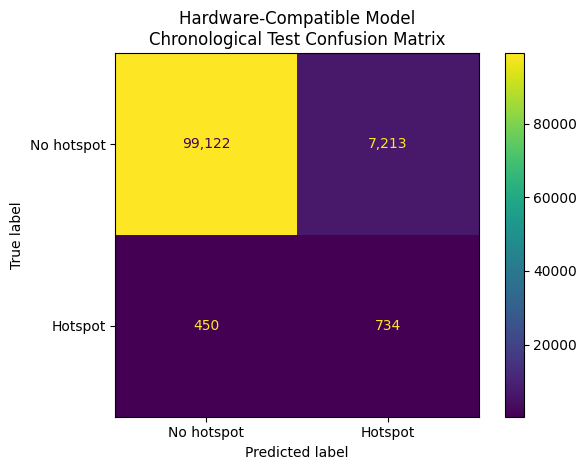

In [31]:
hardware_confusion = confusion_matrix(
    y_test,
    hardware_test_predictions
)

hardware_cm_display = ConfusionMatrixDisplay(
    confusion_matrix=hardware_confusion,
    display_labels=[
        "No hotspot",
        "Hotspot"
    ]
)

hardware_cm_display.plot(
    values_format=",d"
)

plt.title(
    "Hardware-Compatible Model\n"
    "Chronological Test Confusion Matrix"
)

plt.tight_layout()

HARDWARE_CONFUSION_MATRIX_PATH = (
    RESULTS_FOLDER
    / "hardware_model_test_confusion_matrix_v2.png"
)

plt.savefig(
    HARDWARE_CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Test Precision-Recall Curves

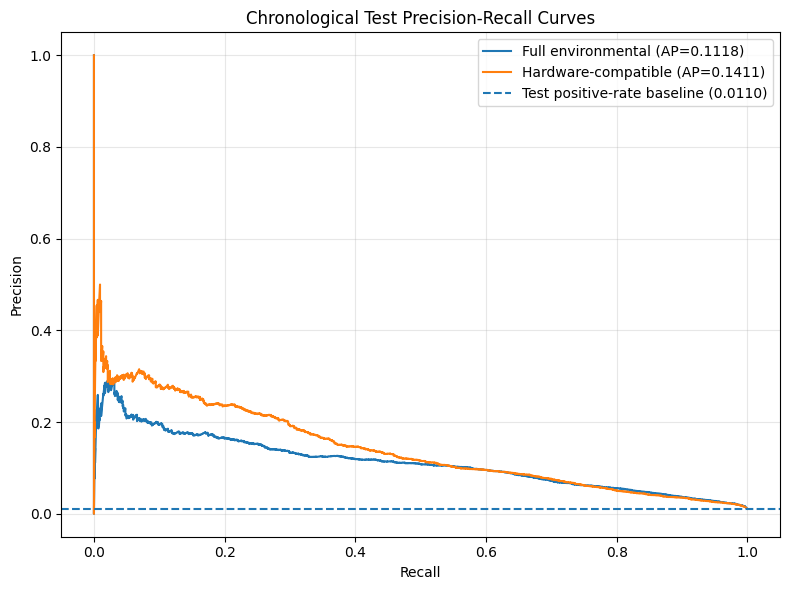

In [32]:
full_test_precision, full_test_recall, _ = (
    precision_recall_curve(
        y_test,
        full_test_scores
    )
)

hardware_test_precision, hardware_test_recall, _ = (
    precision_recall_curve(
        y_test,
        hardware_test_scores
    )
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    full_test_recall,
    full_test_precision,
    label=(
        "Full environmental "
        f"(AP={full_test_average_precision:.4f})"
    )
)

plt.plot(
    hardware_test_recall,
    hardware_test_precision,
    label=(
        "Hardware-compatible "
        f"(AP={hardware_test_average_precision:.4f})"
    )
)

plt.axhline(
    y=full_test_baseline_rate,
    linestyle="--",
    label=(
        "Test positive-rate baseline "
        f"({full_test_baseline_rate:.4f})"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Chronological Test Precision-Recall Curves"
)
plt.legend()
plt.grid(
    alpha=0.3
)
plt.tight_layout()

PR_CURVE_PATH = (
    RESULTS_FOLDER
    / "model_comparison_test_precision_recall_v2.png"
)

plt.savefig(
    PR_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 16. Feature Importance

In [33]:
def create_feature_importance(
    model,
    feature_columns
):
    return (
        pd.DataFrame({
            "feature": feature_columns,
            "importance": (
                model.feature_importances_
            ),
        })
        .sort_values(
            "importance",
            ascending=False
        )
        .reset_index(drop=True)
    )


full_feature_importance = (
    create_feature_importance(
        full_model,
        FULL_MODEL_FEATURES
    )
)

hardware_feature_importance = (
    create_feature_importance(
        hardware_model,
        HARDWARE_MODEL_FEATURES
    )
)

full_feature_importance.head(15)

,feature,importance
0,month,0.082721
1,relative_humidity,0.077380
2,day_of_year_sin,0.068828
3,humidity_mean_3d,0.065351
4,humidity_mean_7d,0.049866
5,precipitation_mm,0.041766
6,temperature_max_c,0.040505
7,temperature_max_3d,0.036988
8,rainfall_sum_14d,0.036671
9,day_of_year_cos,0.034782


In [34]:
hardware_feature_importance.head(15)

,feature,importance
0,relative_humidity,0.110266
1,month,0.109169
2,day_of_year_sin,0.082329
3,humidity_mean_3d,0.078253
4,humidity_mean_7d,0.069035
5,temperature_max_c,0.058829
6,day_of_year_cos,0.057619
7,temperature_max_3d,0.050076
8,temperature_max_7d,0.046321
9,temperature_mean_c,0.040610


In [35]:
FULL_FEATURE_IMPORTANCE_PATH = (
    RESULTS_FOLDER
    / "full_model_feature_importance_v2.csv"
)

HARDWARE_FEATURE_IMPORTANCE_PATH = (
    RESULTS_FOLDER
    / "hardware_model_feature_importance_v2.csv"
)

full_feature_importance.to_csv(
    FULL_FEATURE_IMPORTANCE_PATH,
    index=False
)

hardware_feature_importance.to_csv(
    HARDWARE_FEATURE_IMPORTANCE_PATH,
    index=False
)

print(
    "Saved full feature importance:",
    FULL_FEATURE_IMPORTANCE_PATH
)

print(
    "Saved hardware feature importance:",
    HARDWARE_FEATURE_IMPORTANCE_PATH
)

Saved full feature importance: /content/drive/MyDrive/Wildfire_ML_Project/results/full_model_feature_importance_v2.csv
Saved hardware feature importance: /content/drive/MyDrive/Wildfire_ML_Project/results/hardware_model_feature_importance_v2.csv


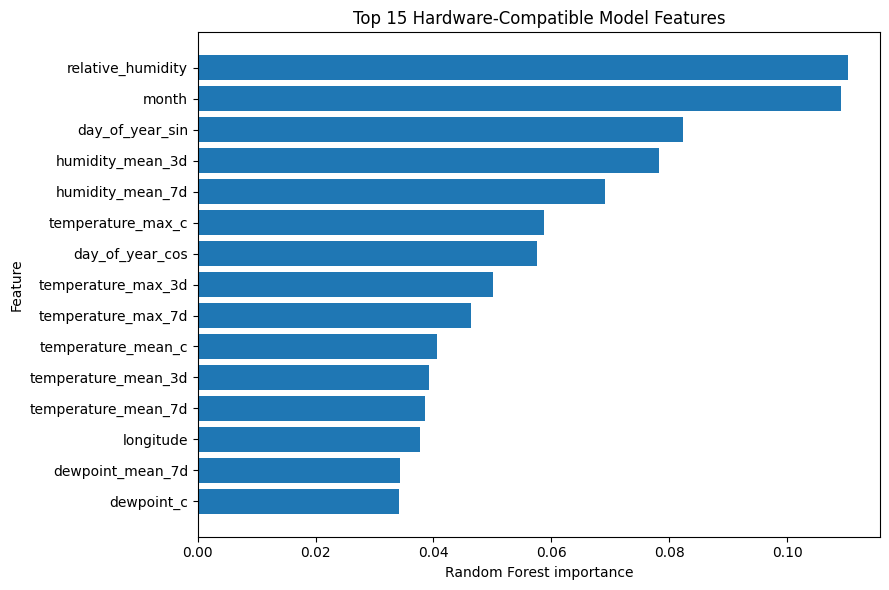

In [36]:
top_hardware_features = (
    hardware_feature_importance
    .head(15)
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    top_hardware_features[
        "feature"
    ][::-1],
    top_hardware_features[
        "importance"
    ][::-1]
)

plt.xlabel(
    "Random Forest importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 15 Hardware-Compatible Model Features"
)

plt.tight_layout()

HARDWARE_IMPORTANCE_PLOT_PATH = (
    RESULTS_FOLDER
    / "hardware_model_feature_importance_top15_v2.png"
)

plt.savefig(
    HARDWARE_IMPORTANCE_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 17. Save the Final Model Bundles

The full model is retained as the research benchmark.

The hardware-compatible model is the deployment model. Its bundle contains:

- trained classifier
- exact feature order
- validation-derived risk thresholds
- training-grid coordinates for location snapping
- daily aggregation definitions
- sensor data-quality rules
- required history length
- model and library versions

In [37]:
FULL_MODEL_PATH = (
    MODEL_FOLDER
    / "wildfire_full_environmental_next_day_v1.joblib"
)

HARDWARE_MODEL_PATH = (
    MODEL_FOLDER
    / "wildfire_hardware_next_day_v1.joblib"
)

created_at_utc = datetime.now(
    timezone.utc
).isoformat()

split_periods = {
    "training": {
        "start": str(
            wildfire.loc[
                train_mask,
                "date"
            ].min().date()
        ),
        "end": str(
            wildfire.loc[
                train_mask,
                "date"
            ].max().date()
        ),
    },
    "validation": {
        "start": str(
            wildfire.loc[
                validation_mask,
                "date"
            ].min().date()
        ),
        "end": str(
            wildfire.loc[
                validation_mask,
                "date"
            ].max().date()
        ),
    },
    "testing": {
        "start": str(
            wildfire.loc[
                test_mask,
                "date"
            ].min().date()
        ),
        "end": str(
            wildfire.loc[
                test_mask,
                "date"
            ].max().date()
        ),
    },
}

training_grid = (
    wildfire[
        ["latitude", "longitude"]
    ]
    .drop_duplicates()
    .sort_values(
        ["latitude", "longitude"]
    )
    .reset_index(drop=True)
)

assert len(training_grid) == 1361

common_bundle_metadata = {
    "target": "fire_next_day",
    "target_definition": (
        "NASA FIRMS active-fire hotspot detection "
        "in the same ERA5 grid cell on the following day."
    ),
    "forecast_horizon_hours": 24,
    "training_dataset": str(
        BASE_DATASET_PATH
    ),
    "created_at_utc": created_at_utc,
    "random_state": RANDOM_STATE,
    "sklearn_version": (
        sklearn.__version__
    ),
    "split_periods": split_periods,
    "score_interpretation": (
        "Random Forest next-day wildfire risk score. "
        "It is not a calibrated physical probability "
        "of ignition."
    ),
}

full_model_bundle = {
    **common_bundle_metadata,
    "model_version": (
        "wildfire_full_environmental_next_day_v1"
    ),
    "model": full_model,
    "feature_columns": (
        FULL_MODEL_FEATURES
    ),
    "risk_thresholds": (
        full_thresholds
    ),
    "deployment_scope": (
        "Regional ERA5-Land grid-cell "
        "next-day risk mapping."
    ),
}

hardware_feature_definitions = {
    "temperature_mean_c": (
        "Mean of all valid DHT11 temperature "
        "readings in the completed daily window."
    ),
    "temperature_max_c": (
        "Maximum valid DHT11 temperature in the "
        "completed daily window."
    ),
    "relative_humidity": (
        "Mean of all valid DHT11 humidity readings "
        "in the completed daily window."
    ),
    "dewpoint_c": (
        "Mean daily dew point calculated from each "
        "valid temperature-humidity reading."
    ),
    "humidity_mean_3d": (
        "Mean of the latest three daily relative-"
        "humidity summaries."
    ),
    "humidity_mean_7d": (
        "Mean of the latest seven daily relative-"
        "humidity summaries."
    ),
    "temperature_mean_3d": (
        "Mean of the latest three daily mean-"
        "temperature summaries."
    ),
    "temperature_mean_7d": (
        "Mean of the latest seven daily mean-"
        "temperature summaries."
    ),
    "temperature_max_3d": (
        "Maximum of the latest three daily maximum "
        "temperatures."
    ),
    "temperature_max_7d": (
        "Maximum of the latest seven daily maximum "
        "temperatures."
    ),
    "dewpoint_mean_3d": (
        "Mean of the latest three daily dew-point "
        "summaries."
    ),
    "dewpoint_mean_7d": (
        "Mean of the latest seven daily dew-point "
        "summaries."
    ),
}

hardware_deployment_contract = {
    "prediction_frequency": (
        "Once per completed daily sensor window."
    ),
    "forecast_horizon_hours": 24,
    "required_history_days": 7,
    "raw_sensor_fields": [
        "sender",
        "temp",
        "hum",
        "lat",
        "lng",
        "gpsFix",
        "timestamp",
    ],
    "reactive_fields_not_used_by_ml": [
        "mq2",
        "flame",
    ],
    "invalid_sensor_reading_rule": (
        "Discard a reading when temp == -1, "
        "hum == -1, either field is missing or "
        "non-numeric, or humidity is outside 0-100."
    ),
    "minimum_daily_valid_reading_percentage": 80.0,
    "location_rule": (
        "Use live GPS when available, otherwise the "
        "last valid GPS location, otherwise a sender-"
        "specific configured deployment coordinate. "
        "Snap that position to the nearest coordinate "
        "in training_grid before inference."
    ),
    "feature_definitions": (
        hardware_feature_definitions
    ),
    "prediction_semantics": (
        "Predictive next-day regional hotspot risk. "
        "Flame and MQ2 alerts remain immediate and "
        "have higher operational priority."
    ),
}

hardware_model_bundle = {
    **common_bundle_metadata,
    "model_version": (
        "wildfire_hardware_next_day_v1"
    ),
    "model": hardware_model,
    "feature_columns": (
        HARDWARE_MODEL_FEATURES
    ),
    "risk_thresholds": (
        hardware_thresholds
    ),
    "training_grid": (
        training_grid
    ),
    "deployment_scope": (
        "Raspberry Pi next-day wildfire risk "
        "inference for each ESP8266 sensor zone."
    ),
    "deployment_contract": (
        hardware_deployment_contract
    ),
}

joblib.dump(
    full_model_bundle,
    FULL_MODEL_PATH
)

joblib.dump(
    hardware_model_bundle,
    HARDWARE_MODEL_PATH
)

print(
    "Saved full model:",
    FULL_MODEL_PATH
)

print(
    "Saved hardware deployment model:",
    HARDWARE_MODEL_PATH
)

Saved full model: /content/drive/MyDrive/Wildfire_ML_Project/models/wildfire_full_environmental_next_day_v1.joblib
Saved hardware deployment model: /content/drive/MyDrive/Wildfire_ML_Project/models/wildfire_hardware_next_day_v1.joblib


In [38]:
HARDWARE_CONTRACT_PATH = (
    RESULTS_FOLDER
    / "hardware_model_contract_v1.json"
)

TRAINING_GRID_PATH = (
    RESULTS_FOLDER
    / "era5_training_grid_v1.csv"
)

training_grid.to_csv(
    TRAINING_GRID_PATH,
    index=False
)

with open(
    HARDWARE_CONTRACT_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        {
            "model_version": (
                hardware_model_bundle[
                    "model_version"
                ]
            ),
            "feature_columns": (
                HARDWARE_MODEL_FEATURES
            ),
            "risk_thresholds": (
                hardware_thresholds
            ),
            "deployment_contract": (
                hardware_deployment_contract
            ),
            "training_grid_path": str(
                TRAINING_GRID_PATH
            ),
        },
        file,
        indent=2
    )

print(
    "Saved hardware contract:",
    HARDWARE_CONTRACT_PATH
)

print(
    "Saved ERA5 training grid:",
    TRAINING_GRID_PATH
)

Saved hardware contract: /content/drive/MyDrive/Wildfire_ML_Project/results/hardware_model_contract_v1.json
Saved ERA5 training grid: /content/drive/MyDrive/Wildfire_ML_Project/results/era5_training_grid_v1.csv


## 18. Verify Saved Hardware Model

In [39]:
loaded_hardware_bundle = joblib.load(
    HARDWARE_MODEL_PATH
)

sample_features = X_hardware_test.iloc[[0]]

in_memory_score = (
    hardware_model.predict_proba(
        sample_features
    )[0, 1]
)

saved_model_score = (
    loaded_hardware_bundle[
        "model"
    ]
    .predict_proba(
        sample_features[
            loaded_hardware_bundle[
                "feature_columns"
            ]
        ]
    )[0, 1]
)

print(
    "In-memory risk score:",
    in_memory_score
)

print(
    "Saved-model risk score:",
    saved_model_score
)

assert np.isclose(
    in_memory_score,
    saved_model_score
)

print(
    "Saved hardware model verification passed."
)

In-memory risk score: 0.048112623590534184
Saved-model risk score: 0.048112623590534184
Saved hardware model verification passed.


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


## 19. Latest Hardware-Compatible Spatial Risk Surface

In [40]:
LATEST_MODELLING_DATE = wildfire[
    "date"
].max()

latest_day = (
    wildfire.loc[
        wildfire["date"]
        == LATEST_MODELLING_DATE
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(latest_day) == 1361

latest_day["hardware_risk_score"] = (
    hardware_model.predict_proba(
        latest_day[
            HARDWARE_MODEL_FEATURES
        ]
    )[:, 1]
)

latest_day["hardware_risk_level"] = [
    assign_risk_level(
        risk_score,
        hardware_thresholds
    )
    for risk_score in latest_day[
        "hardware_risk_score"
    ]
]

latest_hardware_predictions = (
    latest_day[
        [
            "date",
            "latitude",
            "longitude",
            "hardware_risk_score",
            "hardware_risk_level",
        ]
    ]
    .sort_values(
        "hardware_risk_score",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Input date:",
    LATEST_MODELLING_DATE.date()
)

print(
    "Forecast date:",
    (
        LATEST_MODELLING_DATE
        + pd.Timedelta(days=1)
    ).date()
)

latest_hardware_predictions.head(20)

Input date: 2026-05-18
Forecast date: 2026-05-19


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


,date,latitude,longitude,hardware_risk_score,hardware_risk_level
0,2026-05-18,28.799720,81.601197,0.126854,high
1,2026-05-18,29.499723,80.501192,0.122041,high
2,2026-05-18,28.799720,81.501196,0.117376,high
3,2026-05-18,28.699719,81.501196,0.116984,high
4,2026-05-18,29.599723,80.501192,0.115473,high
5,2026-05-18,29.699724,80.601192,0.112413,high
6,2026-05-18,28.799720,81.401196,0.108941,high
7,2026-05-18,28.899720,81.501196,0.106690,high
8,2026-05-18,28.699719,81.601197,0.102329,high
9,2026-05-18,28.599719,81.501196,0.099021,high


In [41]:
hardware_risk_summary = (
    latest_hardware_predictions[
        "hardware_risk_level"
    ]
    .value_counts()
    .reindex(
        [
            "low",
            "moderate",
            "high",
            "very_high",
        ],
        fill_value=0
    )
    .rename_axis(
        "risk_level"
    )
    .reset_index(
        name="grid_cells"
    )
)

hardware_risk_summary

,risk_level,grid_cells
0,low,907
1,moderate,256
2,high,198
3,very_high,0


In [42]:
LATEST_HARDWARE_CSV_PATH = (
    RESULTS_FOLDER
    / "latest_hardware_next_day_risk_v1.csv"
)

LATEST_HARDWARE_PARQUET_PATH = (
    RESULTS_FOLDER
    / "latest_hardware_next_day_risk_v1.parquet"
)

latest_hardware_predictions.to_csv(
    LATEST_HARDWARE_CSV_PATH,
    index=False
)

latest_hardware_predictions.to_parquet(
    LATEST_HARDWARE_PARQUET_PATH,
    index=False,
    engine="pyarrow"
)

print(
    "Saved latest hardware-compatible CSV:",
    LATEST_HARDWARE_CSV_PATH
)

print(
    "Saved latest hardware-compatible Parquet:",
    LATEST_HARDWARE_PARQUET_PATH
)

Saved latest hardware-compatible CSV: /content/drive/MyDrive/Wildfire_ML_Project/results/latest_hardware_next_day_risk_v1.csv
Saved latest hardware-compatible Parquet: /content/drive/MyDrive/Wildfire_ML_Project/results/latest_hardware_next_day_risk_v1.parquet


## 20. Save a Deployment Feature Example

This file records the exact feature names and order expected by the Raspberry
Pi inference service.

In [43]:
DEPLOYMENT_FEATURE_EXAMPLE_PATH = (
    RESULTS_FOLDER
    / "hardware_feature_example_v1.json"
)

highest_risk_example = (
    latest_day
    .sort_values(
        "hardware_risk_score",
        ascending=False
    )
    .iloc[0]
)

deployment_feature_example = {
    "model_version": (
        hardware_model_bundle[
            "model_version"
        ]
    ),
    "input_date": str(
        highest_risk_example[
            "date"
        ].date()
    ),
    "forecast_date": str(
        (
            highest_risk_example[
                "date"
            ]
            + pd.Timedelta(days=1)
        ).date()
    ),
    "features": {
        feature: float(
            highest_risk_example[
                feature
            ]
        )
        for feature in (
            HARDWARE_MODEL_FEATURES
        )
    },
    "risk_score": float(
        highest_risk_example[
            "hardware_risk_score"
        ]
    ),
    "risk_level": str(
        highest_risk_example[
            "hardware_risk_level"
        ]
    ),
}

with open(
    DEPLOYMENT_FEATURE_EXAMPLE_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        deployment_feature_example,
        file,
        indent=2
    )

print(
    "Saved deployment feature example:",
    DEPLOYMENT_FEATURE_EXAMPLE_PATH
)

Saved deployment feature example: /content/drive/MyDrive/Wildfire_ML_Project/results/hardware_feature_example_v1.json


## 21. Save Final Metrics

In [44]:
final_metrics = {
    "created_at_utc": created_at_utc,
    "dataset": {
        "path": str(
            BASE_DATASET_PATH
        ),
        "rows_before_target_shift": 680_500,
        "modelling_rows": len(wildfire),
        "same_day_positive_labels": (
            same_day_positive_count
        ),
        "post_march_same_day_positive_labels": (
            post_march_same_day_positives
        ),
        "test_next_day_positive_labels": int(
            y_test.sum()
        ),
    },
    "split_summary": (
        split_summary
        .assign(
            first_date=lambda frame:
            frame["first_date"].astype(str),
            last_date=lambda frame:
            frame["last_date"].astype(str),
        )
        .to_dict(
            orient="records"
        )
    ),
    "full_model": {
        "model_path": str(
            FULL_MODEL_PATH
        ),
        "feature_count": len(
            FULL_MODEL_FEATURES
        ),
        "risk_thresholds": (
            full_thresholds
        ),
        "validation": evaluate_predictions(
            y_validation,
            full_validation_scores,
            full_thresholds["very_high"]
        ),
        "test": evaluate_predictions(
            y_test,
            full_test_scores,
            full_thresholds["very_high"]
        ),
    },
    "hardware_model": {
        "model_path": str(
            HARDWARE_MODEL_PATH
        ),
        "feature_count": len(
            HARDWARE_MODEL_FEATURES
        ),
        "risk_thresholds": (
            hardware_thresholds
        ),
        "validation": evaluate_predictions(
            y_validation,
            hardware_validation_scores,
            hardware_thresholds["very_high"]
        ),
        "test": evaluate_predictions(
            y_test,
            hardware_test_scores,
            hardware_thresholds["very_high"]
        ),
    },
}

FINAL_METRICS_PATH = (
    RESULTS_FOLDER
    / "model_metrics_v1.json"
)

with open(
    FINAL_METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_metrics,
        file,
        indent=2
    )

print(
    "Saved final metrics:",
    FINAL_METRICS_PATH
)

Saved final metrics: /content/drive/MyDrive/Wildfire_ML_Project/results/model_metrics_v1.json


## 22. Final Completion Checklist

The model is complete only when all of the following are true:

- The corrected Parquet loads successfully.
- Training, validation, and testing all contain positive next-day labels.
- Both the full and hardware-compatible models train successfully.
- Validation and test metrics are finite.
- Risk-level thresholds are derived from validation data only.
- `wildfire_hardware_next_day_v1.joblib` is saved and reloads successfully.
- `hardware_model_contract_v1.json` is created.
- `era5_training_grid_v1.csv` is created.
- `hardware_feature_example_v1.json` is created.
- Latest next-day spatial risk outputs are saved.

After these checks pass, the next stage is Raspberry Pi implementation:

1. Aggregate valid DHT11 readings into daily summaries.
2. Maintain seven days of sender-specific history.
3. Calculate dew point.
4. Snap the sender location to the saved ERA5 training grid.
5. Build the exact saved feature vector.
6. Load `wildfire_hardware_next_day_v1.joblib`.
7. Upload the risk score and risk level to Firebase.
8. Preserve flame and MQ2 as immediate higher-priority alerts.